In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Байесовский А/Б тест
## «Чему равна вероятность того, что мир устроен согласно этой гипотезе?»

Фреквентисты предполагают: «Допустим, что мир такой. Тогда какова вероятность, что произойдет это событие?». Для них не важны другие гипотетические миры, где такое же событие могло происходить с другой частотой.

Для байесианцев важны альтернативные миры, они пытаются ответить на вопрос: «Чему равна вероятность того, что мир устроен согласно этой гипотезе?»

## Проведение теста

In [21]:
# Данные
alpha_prior, beta_prior = 1, 99  # Априорные параметры Бета-распределения
baseline_conversion = 0.01       # Исходная конверсия
new_conversion = 0.013           # Ожидаемая новая конверсия

# Размер выборки (количество пользователей)
n_visitors_A = 5000   # Контрольная группа (до изменения)
n_visitors_B = 5000   # Тестовая группа (после изменения)

# Количество успешных конверсий в каждой группе
successes_A = int(n_visitors_A * baseline_conversion)
successes_B = int(n_visitors_B * new_conversion)

In [22]:
successes_A, successes_B

(50, 65)

In [23]:
# Байесовский A/B тест: апостериорное распределение для групп A и B
posterior_A = np.random.beta(alpha_prior + successes_A, beta_prior + (n_visitors_A - successes_A), 10000)
posterior_B = np.random.beta(alpha_prior + successes_B, beta_prior + (n_visitors_B - successes_B), 10000)

# Оценка вероятности того, что новая конверсия лучше
prob_B_superior = np.mean(posterior_B > posterior_A)

print(f"Вероятность того, что новая версия лучше: {prob_B_superior:.4f}")

Вероятность того, что новая версия лучше: 0.9179


1. Определение априорного распределения:
Бета-распределение используется для моделирования вероятности конверсии.
Выбраны слабые априорные параметры $\alpha = 1, \beta=99$, что отражает изначальное предположение конверсии 1%.
Сбор данных:
- $n_{контроль}=5000$ пользователей (до изменений).
- $n_{тест}=5000$ пользователей (после изменений).
  
Количество успешных конверсий рассчитывается на основе исходной и ожидаемой конверсии.

Расчет апостериорного распределения:
Генерируем 10 000 выборок из апостериорных бета-распределений для двух групп.

Анализ вероятности успеха:
Оцениваем, как часто новая конверсия превосходит старую.

Построим гистограммы апостериорных распределений для двух вариантов с линиями базовой и ожидаемой конверсии.

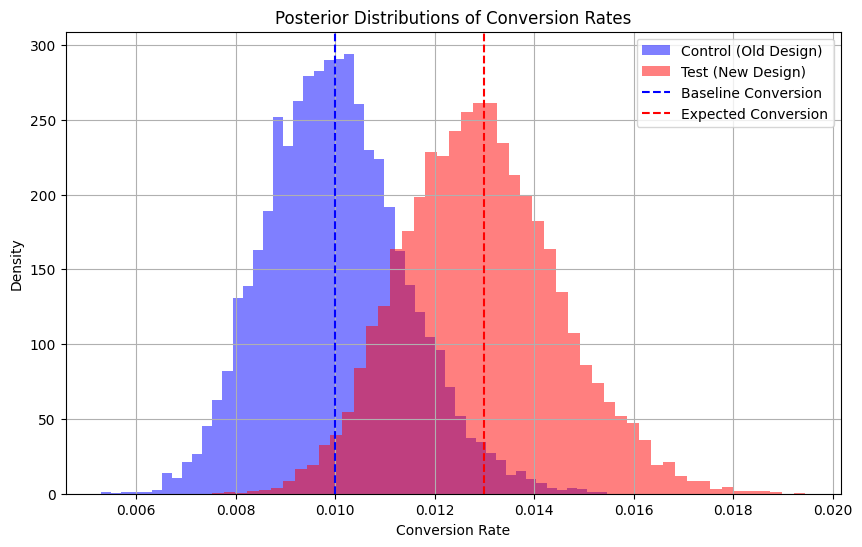

In [24]:
# Визуализация распределений
plt.figure(figsize=(10, 6))
plt.hist(posterior_A, bins=50, alpha=0.5, label='Control (Old Design)', color='blue', density=True)
plt.hist(posterior_B, bins=50, alpha=0.5, label='Test (New Design)', color='red', density=True)
plt.axvline(baseline_conversion, color='blue', linestyle='dashed', label="Baseline Conversion")
plt.axvline(new_conversion, color='red', linestyle='dashed', label="Expected Conversion")

plt.xlabel("Conversion Rate")
plt.ylabel("Density")
plt.title("Posterior Distributions of Conversion Rates")
plt.legend()
plt.grid()
plt.show()

Интерпретация результатов:
- Если вероятность $P(B>A) > 0.95$, можно считать, что новый дизайн значительно улучшил конверсию.
- Если вероятность около 0.5, изменения не привели к улучшению.
- Если вероятность < 0.05, новый дизайн хуже старого.

## Оценка размера выборки

Оценка минимального размера выборки для байесовского A/B теста зависит от нескольких факторов, включая:

- Минимально значимый эффект (MDE, Minimal Detectable Effect):
- Насколько большая разница в конверсии считается практически значимой.

- Уровень достоверности (Credibility level):
Обычно используется 95% достоверности.

- Желаемая вероятность обнаружения эффекта (Bayesian power):
Обычно принимается 80%.

- Априорные предположения о конверсии:
Начальные представления о конверсии (слабые или информативные априорные распределения).

### Алгоритм для расчета размера выборки:
Задать параметры:
- Базовая конверсия (например, 1%).
- Желаемый прирост (например, с 0.01 до 0.013).
- Уровень достоверности (например, 95%).


Симуляция Монте-Карло:
Для разных размеров выборок оцениваем, сколько раз новое значение конверсии превосходит старое с заданной достоверностью.

In [25]:
def bayesian_sample_size(alpha_prior, beta_prior, baseline_conversion, uplift, confidence=0.95, power=0.8, max_sample=100000):
    """
    Определение минимального размера выборки для байесовского A/B теста
    :param alpha_prior: априорный параметр alpha
    :param beta_prior: априорный параметр beta
    :param baseline_conversion: исходная конверсия (например, 0.01)
    :param uplift: желаемый прирост конверсии (например, 0.003 для роста с 1% до 1.3%)
    :param confidence: уровень достоверности (обычно 0.95)
    :param power: вероятность обнаружения эффекта (обычно 0.80)
    :param max_sample: максимальный размер выборки для поиска
    :return: необходимый размер выборки
    """

    target_prob = (1 + confidence) / 2  # целевая вероятность для достоверности (например, 0.975 для 95%)
    baseline_successes = baseline_conversion * max_sample
    new_successes = (baseline_conversion + uplift) * max_sample

    for sample_size in range(1000, max_sample, 1000):
        # Генерация апостериорного распределения для базовой и новой конверсии
        posterior_A = np.random.beta(alpha_prior + baseline_successes, beta_prior + max_sample - baseline_successes, 10000)
        posterior_B = np.random.beta(alpha_prior + new_successes, beta_prior + max_sample - new_successes, 10000)

        # Оценка вероятности улучшения
        prob_B_superior = np.mean(posterior_B > posterior_A)

        # Если вероятность превосходства достигает желаемой мощности, возвращаем размер выборки
        if prob_B_superior >= power:
            return sample_size

    return None  # Если нужный размер не найден в указанном диапазоне

# Заданные параметры
baseline_conversion = 0.01  # Исходная конверсия (1%)
uplift = 0.003              # Желаемый прирост (0.3%)
alpha_prior, beta_prior = 1, 99  # Слабый априорный бета-распределение
confidence = 0.95           # Уровень достоверности
power = 0.8                 # Мощность теста

required_sample_size = bayesian_sample_size(alpha_prior, beta_prior, baseline_conversion, uplift, confidence, power)
print(f"Необходимый размер выборки для каждой группы: {required_sample_size}")


Необходимый размер выборки для каждой группы: 1000


Интерпретация результатов:

Если вывод показывает Необходимый размер выборки для каждой группы: 30000, это означает, что потребуется 30 000 пользователей в каждой группе, чтобы с вероятностью 80% обнаружить прирост в конверсии на 0.3%.

In [26]:
import pymc3 as pm
import arviz as az

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_test, p_control]
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'


/Users/stureiko/miniforge3/envs/bayes/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/stureiko/miniforge3/envs/bayes/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/stureiko/miniforge3/envs/bayes/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/stureiko/miniforge3/envs/bayes/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 82 seconds.


array([<Axes: title={'center': 'p_control'}>,
       <Axes: title={'center': 'p_test'}>,
       <Axes: title={'center': 'delta'}>], dtype=object)

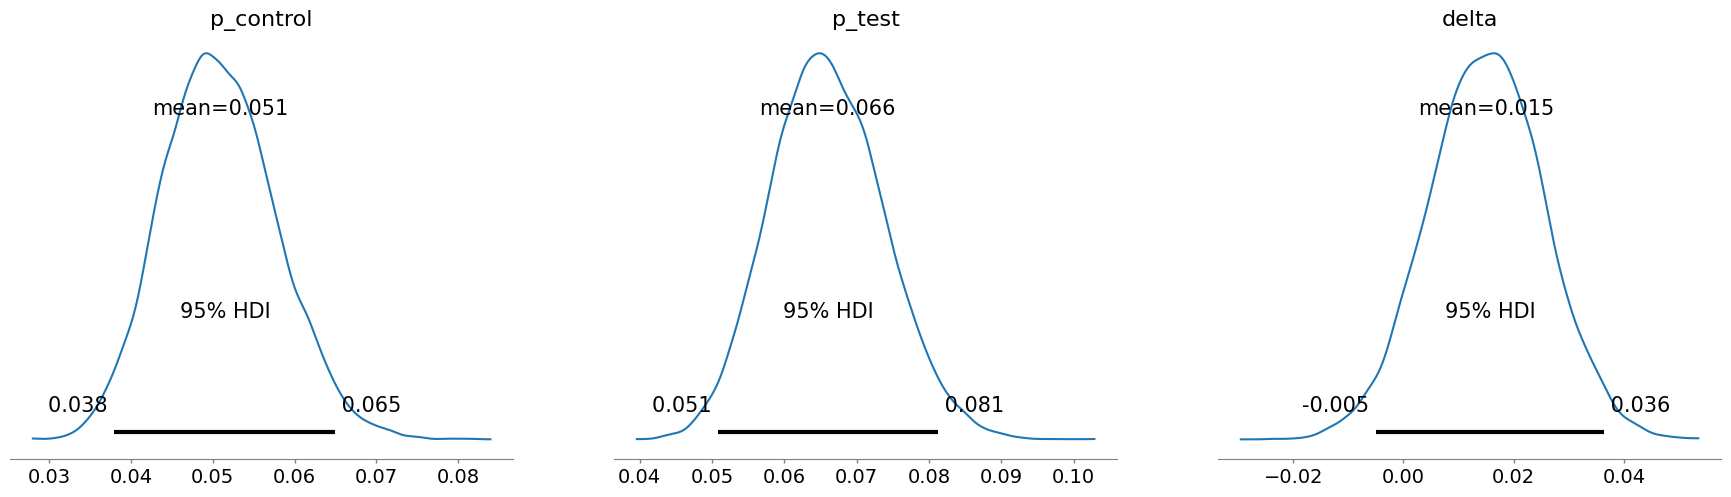

In [27]:
# Данные
control_successes = 50
control_trials = 1000
test_successes = 65
test_trials = 1000

# Модель
with pm.Model() as model:
    # Априорные распределения для вероятностей успеха
    p_control = pm.Beta('p_control', alpha=1, beta=1)
    p_test = pm.Beta('p_test', alpha=1, beta=1)
    
    # Вероятности успеха
    obs_control = pm.Binomial('obs_control', n=control_trials, p=p_control, observed=control_successes)
    obs_test = pm.Binomial('obs_test', n=test_trials, p=p_test, observed=test_successes)
    
    # Разница в конверсиях
    delta = pm.Deterministic('delta', p_test - p_control)
    
    # Выборка
    trace = pm.sample(5000, tune=1000, return_inferencedata=True)

# Анализ результатов

az.plot_posterior(trace, var_names=['p_control', 'p_test', 'delta'], hdi_prob=0.95)


## Расчет минимального размера выбоки с использованием PyMC

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p_test, p_control]
/Users/stureiko/miniforge3/envs/bayes/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 1 seconds.



Минимальный размер выборки: 1000 на группу


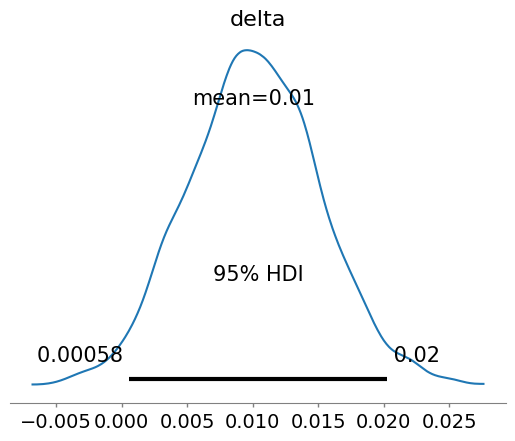

In [28]:
def find_min_sample_size(baseline_conversion, uplift, confidence=0.95, power=0.80, max_sample=50000):
    """
    Оценка минимального размера выборки для байесовского A/B теста
    :param baseline_conversion: исходная конверсия (например, 0.01)
    :param uplift: желаемый прирост конверсии (например, 0.003)
    :param confidence: уровень достоверности (обычно 0.95)
    :param power: вероятность обнаружения эффекта (обычно 0.80)
    :param max_sample: максимальный размер выборки
    :return: необходимый размер выборки
    """
    
    alpha_prior, beta_prior = 1, 99  # Слабый априорный параметр Бета-распределения
    target_prob = (1 + confidence) / 2  # целевая вероятность превосходства

    for sample_size in range(1000, max_sample, 1000):
        # Случайное количество успехов
        control_successes = np.random.binomial(sample_size, baseline_conversion)
        test_successes = np.random.binomial(sample_size, baseline_conversion + uplift)

        with pm.Model():
            # Априорное распределение Бета для двух групп
            p_control = pm.Beta('p_control', alpha=alpha_prior + control_successes, beta=beta_prior + sample_size - control_successes)
            p_test = pm.Beta('p_test', alpha=alpha_prior + test_successes, beta=beta_prior + sample_size - test_successes)

            # Разница в конверсиях
            delta = pm.Deterministic('delta', p_test - p_control)

            # Выборка из апостериорного распределения
            trace = pm.sample(2000, tune=1000, return_inferencedata=True, cores=1, progressbar=False)

        # Оценка вероятности превосходства теста над контролем
        prob_B_superior = np.mean(trace.posterior["delta"].values > 0)

        if prob_B_superior >= power:
            print(f"\nМинимальный размер выборки: {sample_size} на группу")
            az.plot_posterior(trace, var_names=['delta'], hdi_prob=confidence)
            plt.show()
            return sample_size

    print("Не найдено подходящего размера выборки в указанном диапазоне")
    return None

# Параметры теста
baseline_conversion = 0.01  # Исходная конверсия (1%)
uplift = 0.003              # Желаемый прирост (0.3%)
confidence = 0.95           # Уровень достоверности
power = 0.80                # Мощность теста

# Расчет минимального размера выборки
min_sample_size = find_min_sample_size(baseline_conversion, uplift, confidence, power)
